# 12_时间序列分析方法-向量自回归

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 模拟原始序列是随机游走；VAR 在一阶差分上拟合，再累加还原到原量纲。数据是合成演示，不能据此解释实际经济因果关系。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文和大家详细的聊聊时间序列中的**向量自回归**\~

**向量自回归 是什么？**

向量自回归（Vector AutoRegression，简称VAR）是一种常用的时间序列分析算法，特别适合用来分析多个时间序列之间的相互关系。

假设我们有多个时间序列数据，彼此之间可能存在某种关联。VAR模型的核心是：每个时间序列的当前值可以通过它自身过去的值和其他时间序列的过去值来预测。

比如，假设我们想预测某个城市的**房价**和**失业率**这两个指标。很可能**房价**会受到之前房价的影响（房价趋势），也会受到失业率的影响（经济因素）；同时，失业率也可能受到之前失业率的影响，还会受房价的影响（生活成本因素）。这时，我们就可以使用VAR模型来捕捉这两个指标的互相影响关系。

### VAR的数学公式

在VAR模型中，如果有两个时间序列 $Y_t$和 $X_t$，那么模型可以表示为：

$Y_t = a_0 + a_1 Y_{t-1} + a_2 X_{t-1} + \epsilon_t^Y$  
$X_t = b_0 + b_1 Y_{t-1} + b_2 X_{t-1} + \epsilon_t^X$

其中：

- $Y_t$和 $X_t$：在时间 $t$的两个时间序列值（比如房价和失业率）。
- $a_0$、$b_0$：常数项。
- $a_1$、$a_2$、$b_1$、$b_2$：回归系数，用来表示各个变量的影响程度。
- $\epsilon_t^Y$、$\epsilon_t^X$：误差项，表示一些不可预测的随机因素。

简单来说，当前的房价和失业率，都会受到它们之前的房价和失业率的影响。

### 简单案例：房价和失业率

假设我们有一组数据：

| 时间 | 房价（万元） | 失业率（%） |
|-|-|-|
| 1 | 100 | 5.0 |
| 2 | 102 | 4.8 |
| 3 | 101 | 5.1 |
| 4 | 103 | 5.0 |
| 5 | ? | ? |

我们的目标是用VAR模型来预测时间点5的房价和失业率。

### VAR模型的计算步骤

**1. 设定模型参数**：假设我们已经计算出回归系数（这里的系数只是虚拟的示例，实际情况需要使用统计软件进行拟合）：

$a_0 = 1$、$a_1 = 0.8$、$a_2 = -0.5$

$b_0 = 2$、$b_1 = -0.3$、$b_2 = 0.6$

**2. 建立方程**：根据这些系数，模型的方程可以写为：

$\text{房价}_t = 1 + 0.8 \times \text{房价}_{t-1} - 0.5 \times \text{失业率}_{t-1}$  
$\text{失业率}_t = 2 - 0.3 \times \text{房价}_{t-1} + 0.6 \times \text{失业率}_{t-1}$

**3. 代入数值**：使用时间点4的数据（房价=103，失业率=5.0），代入上面的方程，计算时间点5的预测值：

- 房价预测：$\text{房价}_5 = 1 + 0.8 \times 103 - 0.5 \times 5.0 = 1 + 82.4 - 2.5 = 80.9$
- 失业率预测：$\text{失业率}_5 = 2 - 0.3 \times 103 + 0.6 \times 5.0 = 2 - 30.9 + 3.0 = -25.9$

在这个例子里，VAR模型通过时间点4的房价和失业率数据，预测了时间点5的房价为80.9万元，失业率为-25.9%。显然，这个例子数据简单，实际预测结果有些异常（失业率不可能为负），这可能是因为我们假设的系数不够合理。实际应用中，需要更多数据和更精确的系数才能得到真实的结果。

VAR模型适合用于分析多个时间序列之间的关系。它的关键在于利用多个时间序列的历史信息，互相之间的动态关系，为未来的各个时间序列值做出预测。

## 公式解析

给定 $K$个时间序列变量 $Y_1, Y_2, \dots, Y_K$，它们组成了一个 $K$-维向量时间序列 $\mathbf{Y}_t = [Y_{1,t}, Y_{2,t}, \dots, Y_{K,t}]^\top$。VAR(p) 模型的形式为：


$$
\mathbf{Y}_t = \mathbf{c} + \mathbf{A}_1 \mathbf{Y}_{t-1} + \mathbf{A}_2 \mathbf{Y}_{t-2} + \dots + \mathbf{A}_p \mathbf{Y}_{t-p} + \mathbf{u}_t
$$


其中：

- $\mathbf{c}$是 $K \times 1$的常数项向量。
- $\mathbf{A}_i$是 $K \times K$的系数矩阵，表示第 $i$阶滞后时间的系数。
- $\mathbf{u}_t$是 $K \times 1$的误差项向量（噪声），假设 $\mathbf{u}_t$满足独立同分布，即 $\mathbf{u}_t \sim \mathcal{N}(\mathbf{0}, \Sigma)$，其中 $\Sigma$是 $K \times K$的协方差矩阵。

对于 VAR(1) 模型，假设 $K = 2$，即我们有两个变量 $Y_{1,t}$和 $Y_{2,t}$，则模型可以展开为：


$$
\begin{cases}Y_{1,t} = c_1 + a_{11} Y_{1,t-1} + a_{12} Y_{2,t-1} + u_{1,t} \\Y_{2,t} = c_2 + a_{21} Y_{1,t-1} + a_{22} Y_{2,t-1} + u_{2,t}\end{cases}
$$


其中：

- $c_1, c_2$是常数项。
- $a_{11}, a_{12}, a_{21}, a_{22}$是 VAR(1) 模型的系数。
- $u_{1,t}, u_{2,t}$是误差项。

### VAR 模型的矩阵形式推导

将上述 VAR(1) 模型写成矩阵形式，我们得到：


$$
\mathbf{Y}_t = \begin{bmatrix} Y_{1,t} \\ Y_{2,t} \end{bmatrix}, \quad \mathbf{c} = \begin{bmatrix} c_1 \\ c_2 \end{bmatrix}, \quad \mathbf{A}_1 = \begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix}, \quad \mathbf{u}_t = \begin{bmatrix} u_{1,t} \\ u_{2,t} \end{bmatrix}
$$


因此，模型可以写为：


$$
\mathbf{Y}_t = \mathbf{c} + \mathbf{A}_1 \mathbf{Y}_{t-1} + \mathbf{u}_t
$$


### VAR(p) 模型的推广

对于更高阶的模型（VAR(p)），当前时刻的值不仅与上一个时刻的值相关，还与前 $p$个时刻的值相关。具体形式为：


$$
\mathbf{Y}_t = \mathbf{c} + \mathbf{A}_1 \mathbf{Y}_{t-1} + \mathbf{A}_2 \mathbf{Y}_{t-2} + \dots + \mathbf{A}_p \mathbf{Y}_{t-p} + \mathbf{u}_t
$$


其中，$\mathbf{A}_1, \mathbf{A}_2, \dots, \mathbf{A}_p$是每个滞后阶的系数矩阵。

### 参数估计

VAR 模型的参数估计通常通过**最小二乘法**（Ordinary Least Squares, OLS）来进行。对于 VAR(p) 模型，可以将模型转换为多元线性回归问题，利用 OLS 得到系数矩阵的估计值。

#### 构造滞后矩阵

对于样本 $T$和滞后阶数 $p$，构造滞后矩阵 $\mathbf{Z}$为：


$$
\mathbf{Z} =\begin{bmatrix}1 & \mathbf{Y}_{t-1} & \mathbf{Y}_{t-2} & \dots & \mathbf{Y}_{t-p} \\1 & \mathbf{Y}_{t} & \mathbf{Y}_{t-1} & \dots & \mathbf{Y}_{t-p+1} \\\vdots & \vdots & \vdots & \ddots & \vdots \\1 & \mathbf{Y}_{T-1} & \mathbf{Y}_{T-2} & \dots & \mathbf{Y}_{T-p} \\\end{bmatrix}
$$


#### VAR 系数的估计

我们定义 $\mathbf{B} = [\mathbf{c}, \mathbf{A}_1, \dots, \mathbf{A}_p]$为 VAR(p) 模型的参数矩阵。为了估计参数，可以使用以下公式：


$$
\mathbf{B} = (\mathbf{Z}^\top \mathbf{Z})^{-1} \mathbf{Z}^\top \mathbf{Y}
$$


### 预测公式

一旦我们估计出模型参数 $\mathbf{c}, \mathbf{A}_1, \dots, \mathbf{A}_p$，就可以通过以下公式来进行预测：


$$
\hat{\mathbf{Y}}_{T+h} = \mathbf{c} + \mathbf{A}_1 \hat{\mathbf{Y}}_{T+h-1} + \mathbf{A}_2 \hat{\mathbf{Y}}_{T+h-2} + \dots + \mathbf{A}_p \hat{\mathbf{Y}}_{T+h-p}
$$


其中 $h$表示预测的步长。

## 完整案例

在此案例中，我们生成了模拟数据来展示 `VAR` 模型的工作原理。代码实现了模型的拟合和预测，并绘制以下数据分析图：

1. 时间序列图：显示每个经济指标的历史趋势。
2. 预测图：显示未来若干期的预测结果。
3. 残差热力图：展示模型的残差相关性。
4. 相关矩阵图：显示不同指标之间的相关性。

### 完整代码

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11297/2547255567.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range("2021-01-01", periods=n_obs, freq="M")
/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11297/2547255567.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(df.index[-1] + pd.DateOffset(1), periods=12, freq="M")


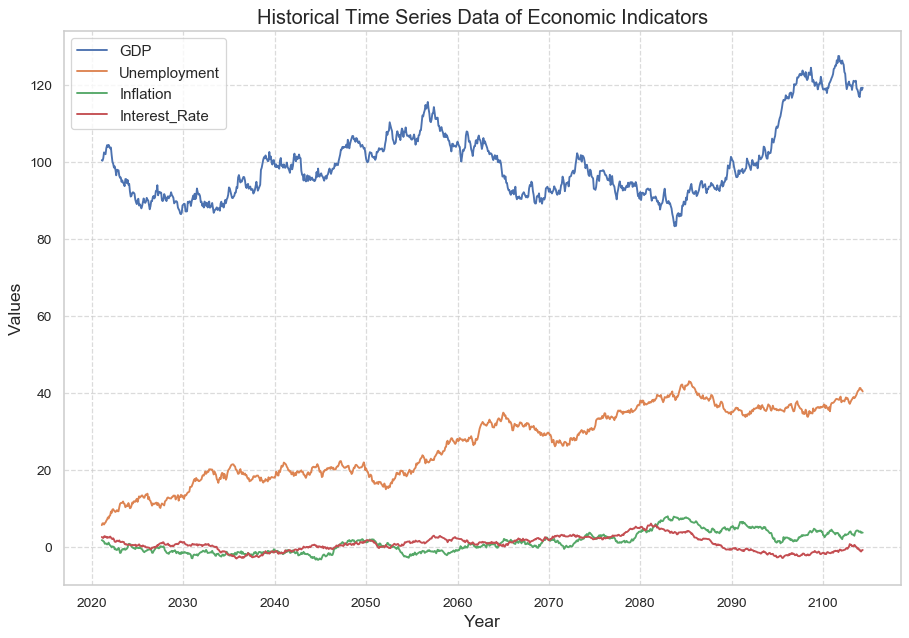

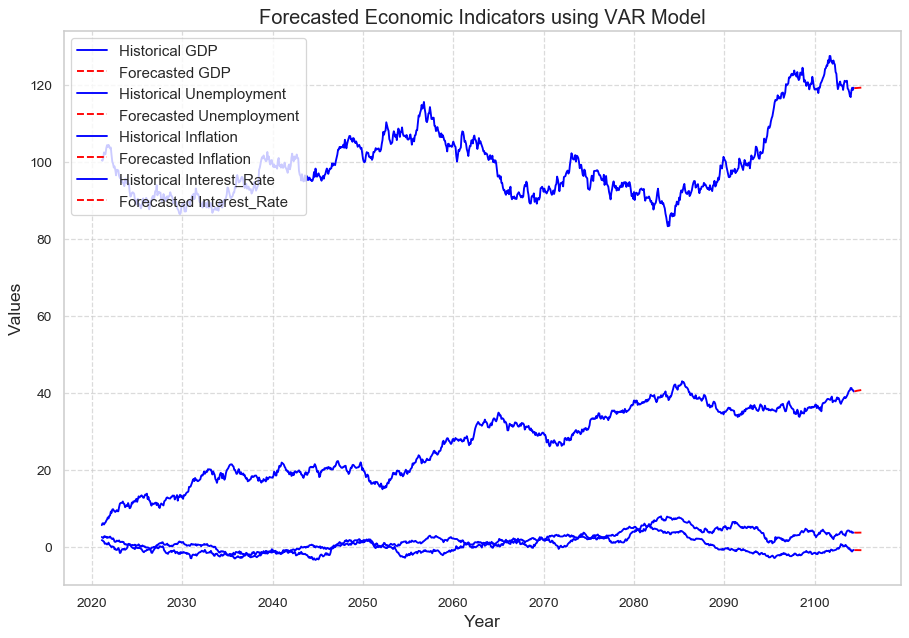

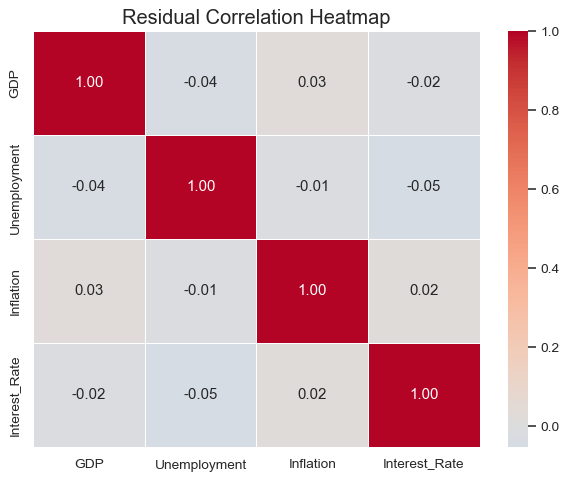

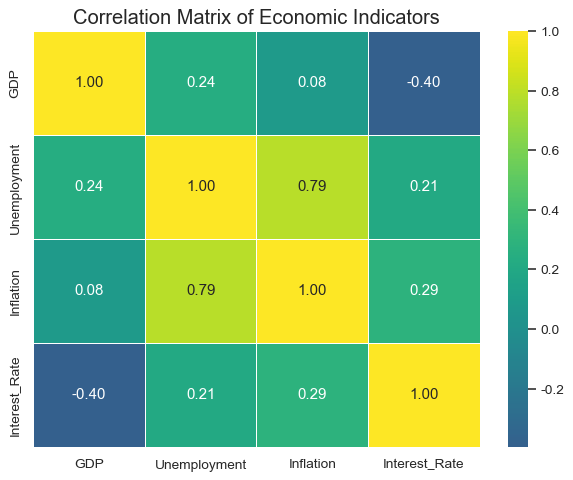

<Figure size 900x360 with 0 Axes>

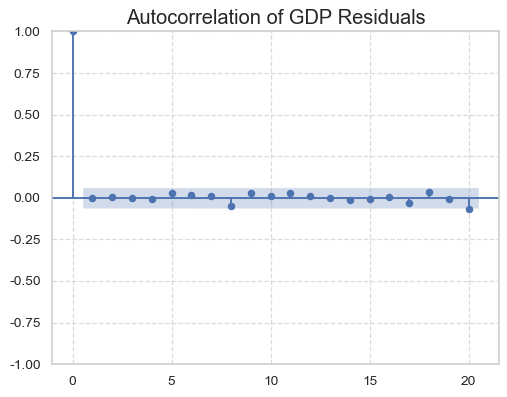

<Figure size 900x360 with 0 Axes>

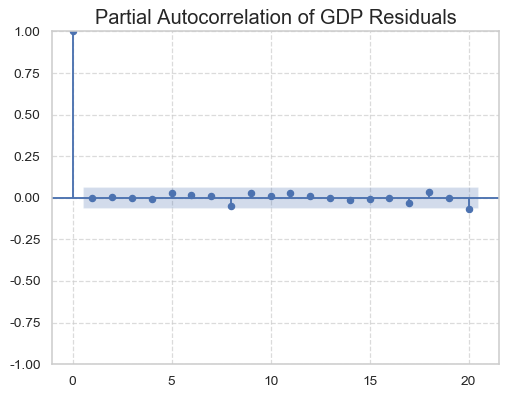

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 设置随机种子和时间序列长度
np.random.seed(42)
n_obs = 1000

# 生成模拟数据：GDP、失业率、通货膨胀率和利率
dates = pd.date_range("2021-01-01", periods=n_obs, freq="M")
data = {
    "GDP": np.cumsum(np.random.normal(0, 1, n_obs)) + 100,
    "Unemployment": np.cumsum(np.random.normal(0, 0.5, n_obs)) + 5,
    "Inflation": np.cumsum(np.random.normal(0, 0.3, n_obs)) + 2,
    "Interest_Rate": np.cumsum(np.random.normal(0, 0.2, n_obs)) + 3,
}
df = pd.DataFrame(data, index=dates)

# 创建并拟合 VAR 模型
model = VAR(df.diff().dropna())
results = model.fit(4)

# 预测未来12期
lag_order = results.k_ar
forecast_diff = results.forecast(model.endog[-lag_order:], steps=12)
forecast = df.iloc[-1].to_numpy() + np.cumsum(forecast_diff, axis=0)
forecast_index = pd.date_range(df.index[-1] + pd.DateOffset(1), periods=12, freq="M")
df_forecast = pd.DataFrame(forecast, index=forecast_index, columns=df.columns)

# 使用 Seaborn 的样式来美化图表
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = CJK_FONTS
# 1. 绘制原始时间序列数据
plt.figure(figsize=(12, 8))
for i, col in enumerate(df.columns):
    plt.plot(df.index, df[col], label=col, linewidth=1.5)
plt.legend(loc="upper left", fontsize=12)
plt.title("Historical Time Series Data of Economic Indicators", fontsize=16, weight="bold")
plt.xlabel("Year", fontsize=14)
plt.ylabel("Values", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2. 预测结果图
plt.figure(figsize=(12, 8))
for col in df.columns:
    plt.plot(df.index, df[col], label=f"Historical {col}", color="blue", linewidth=1.5)
    plt.plot(df_forecast.index, df_forecast[col], label=f"Forecasted {col}", linestyle="--", color="red", linewidth=1.5)
plt.legend(loc="upper left", fontsize=12)
plt.title("Forecasted Economic Indicators using VAR Model", fontsize=16, weight="bold")
plt.xlabel("Year", fontsize=14)
plt.ylabel("Values", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. 残差相关性热力图
residuals = results.resid
plt.figure(figsize=(8, 6))
sns.heatmap(residuals.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("Residual Correlation Heatmap", fontsize=16, weight="bold")
plt.show()

# 4. 经济指标之间的相关性矩阵热力图
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="viridis", center=0, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Economic Indicators", fontsize=16, weight="bold")
plt.show()

# 5. 残差的自相关图（以GDP残差为例）
plt.figure(figsize=(10, 4))
plot_acf(residuals["GDP"], lags=20)
plt.title("Autocorrelation of GDP Residuals", fontsize=16, weight="bold")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 6. 残差的偏自相关图（以GDP残差为例）
plt.figure(figsize=(10, 4))
plot_pacf(residuals["GDP"], lags=20)
plt.title("Partial Autocorrelation of GDP Residuals", fontsize=16, weight="bold")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**1. 时间序列图**：展示了 `GDP`、`Unemployment`、`Inflation` 和 `Interest_Rate` 的历史趋势，帮助观察不同经济指标的变化情况。

![原文参考图，当前结果见代码输出](attachments/img_001.png)

**2. 预测结果图**：蓝色实线表示历史数据，红色虚线表示未来12期的预测数据，便于对未来趋势的可视化分析。

![原文参考图，当前结果见代码输出](attachments/img_002.png)

**3. 残差相关性热力图**：显示不同指标残差间的相关性，帮助评估模型的拟合效果。

![原文参考图，当前结果见代码输出](attachments/img_003.png)

**4. 经济指标的相关性矩阵热力图**：展示不同经济指标之间的相关性，便于理解变量间的关系。

![原文参考图，当前结果见代码输出](attachments/img_004.png)

**5. 残差的自相关图（以GDP残差为例）**：用于检验残差的自相关性，评估模型拟合的残差特性。

![原文参考图，当前结果见代码输出](attachments/img_005.png)

**6. 残差的偏自相关图（以GDP残差为例）**：进一步分析残差的偏自相关性，提供模型诊断依据。

综合上述可视化分析，我们能够深入理解 VAR 模型对宏观经济指标的分析效果，并通过残差分析评估模型的可靠性。

## 优缺点和适用场景

向量自回归（VAR）模型在时间序列分析中非常重要，尤其在分析多个变量相互关系时。

相比其他时间序列模型，VAR 有其独特的优势和局限性。

### 1. VAR 模型的优缺点

#### 优点

- **多变量动态关系**：VAR 模型适合处理多个时间序列变量之间的相互影响。它不仅可以描述一个变量的变化，还能捕捉多个变量之间的交互关系，适合于具有因果联系的多元时间序列数据。
- **相对简单的建模和解释**：VAR 模型结构简单，便于解释。每个变量的值通过滞后期的自己和其他变量的值线性组合表示，这在解释时更直观。
- **灵活性**：VAR 模型允许每个变量使用不同的滞后项组合，适应性较强，尤其在研究变量间短期动态关系时表现优异。

#### 缺点

- **参数估计复杂度高**：当变量较多或滞后阶数较高时，参数的数量会急剧增加，导致模型可能过于复杂、难以解释，且易产生过拟合。
- **线性关系假设**：VAR 是线性模型，无法捕捉变量之间的非线性关系，可能不适合存在显著非线性关系的时间序列。
- **对平稳性的要求**：VAR 模型假设数据是平稳的，不平稳数据需进行差分处理，否则可能导致虚假回归。

### 2. VAR 模型与其他时间序列模型的对比

| 模型 | 优点 | 缺点 | 适用场景 |
|-|-|-|-|
| **VAR** | 适用于多变量关系分析，简单易解释 | 参数多、难以处理非线性、需平稳数据 | 多变量系统，如经济、金融数据 |
| **ARIMA** | 适合单变量预测，处理趋势和季节性 | 仅适合单变量，难以描述变量间的相互影响 | 单变量预测，如温度、销售量 |
| **SARIMA** | ARIMA的扩展，适用于季节性数据 | 仅适合单变量预测，建模复杂度高 | 季节性数据分析，如季节性需求 |
| **GARCH** | 擅长处理波动性较大的数据，常用于金融领域 | 仅适合单变量，难以分析多个变量间的关系 | 金融数据中的波动率预测 |
| **Prophet** | 自动化程度高，适合带有趋势和季节性的单变量 | 参数灵活性较低，对非周期数据效果较差 | 销售、流量等周期性数据预测 |
| **LSTM** | 能捕捉长时依赖，适合处理非线性关系 | 需要大量数据，训练时间长，难以解释 | 非线性、复杂依赖的时间序列，如股票、物联网数据 |

- **ARIMA**：适合单变量时间序列预测，特别是可以处理带有趋势和季节性的单变量时间序列。但是，对于多变量时间序列（如多种经济指标之间的关系），ARIMA 适用性有限。
- **GARCH**：常用于金融数据（如股价、汇率）的波动率预测，GARCH 能很好地处理金融时间序列中的异方差现象。VAR 不考虑异方差性，因此不适合此类波动性较高的数据。
- **LSTM**（Long Short-Term Memory）：一种神经网络模型，适合长时间依赖的非线性时间序列。LSTM 可以捕捉复杂的非线性依赖关系，但训练过程较慢，对大数据量依赖强。

### 3. VAR 模型的适用场景

VAR 模型适合用于分析和预测多个时间序列之间的相互关系，尤其是在经济学和金融学领域得到广泛应用。适用的场景包括：

- **宏观经济分析**：用于研究各项经济指标（如 GDP、利率、通货膨胀率、失业率）之间的相互关系，捕捉经济体系内的动态结构。
- **金融市场分析**：用于分析多个金融市场指标（如股票指数、汇率、利率）之间的动态关系，特别是在风险管理和投资组合分析中。
- **能源市场分析**：用于分析油价、电价、天然气价格之间的相互影响，有助于能源领域的定价和风险管理。
- **区域经济分析**：在区域经济研究中，可以使用 VAR 模型分析区域间的经济依赖关系，如各省市的 GDP 增长率与其他经济变量的关系。
- **医疗和流行病分析**：可用于分析多个健康指标（如感染率、住院率、疫苗接种率）之间的关系，以预测疫情发展。